# Interpretable Road Damage Detection for Intelligent Transportation Systems using YOLOv8 Nano and EigenCAM

## End-to-End Object Detection Pipeline

This notebook presents the complete workflow for developing a custom YOLOv8 Nano model for automated road damage detection. It covers dataset preparation, model training, evaluation, and inference on three road damage classes: **Crack, Manhole, and Pothole**.

The project demonstrates a complete object detection pipeline while emphasizing model interpretability through qualitative analysis of predictions. This notebook forms the core implementation accompanying the GitHub repository.

**Project Status:** ✅ Completed Training & Evaluation Pipeline

In [1]:
# ============================================
# Install Required Libraries
# ============================================

!pip install -q ultralytics

print("✅ Ultralytics Installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.1 MB/s eta 0:00:00
✅ Ultralytics Installed


In [2]:
# ============================================
# Import Libraries
# ============================================

from ultralytics import YOLO

import os
import yaml
import shutil
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries Imported Successfully")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries Imported Successfully


## Environment Setup

In [3]:
# ============================================
# Verify PyTorch installation and GPU availability
# ============================================

import torch

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU : Tesla T4


## Dataset Preparation

A custom road damage dataset was used because the pretrained YOLOv8 Nano model is trained on the COCO dataset, which does not include road-specific defects such as **cracks, manholes, and potholes**.

The dataset follows the standard YOLO object detection format and is organized into separate **training**, **validation**, and **testing** subsets. A `data.yaml` configuration file specifies the dataset structure, class labels, and directory paths required during model training.

## Install Required Libraries

In [4]:
# ==========================================================
# Install required packages
# ==========================================================

!pip install -q kaggle ultralytics

In [5]:
# ==========================================================
# Upload kaggle.json API credentials
# ==========================================================

from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [6]:
# ==========================================================
# Configure Kaggle API credentials
# ==========================================================

import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("✅ Kaggle configured successfully")

✅ Kaggle configured successfully


In [7]:
# ==========================================================
# Download the Road Damage Dataset from Kaggle
# ==========================================================

!kaggle datasets download -d lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes

Dataset URL: https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes
License(s): MIT
100% 185M/185M [00:01<00:00, 119MB/s]



In [8]:
# ============================================
# Verify that the dataset archive was downloaded
# ============================================

import os

for file in os.listdir():
    if file.endswith(".zip"):
        print("ZIP File:", file)
        print("Size (MB):", round(os.path.getsize(file) / (1024*1024), 2))

ZIP File: road-damage-dataset-potholes-cracks-and-manholes.zip
Size (MB): 185.17


In [9]:
# ============================================
# Extract the downloaded dataset
# ============================================

import zipfile

zip_file = "road-damage-dataset-potholes-cracks-and-manholes.zip"
extract_path = "RoadDamageDataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [10]:
# ============================================
# Inspect the extracted dataset structure
# ============================================

from pathlib import Path

dataset_path = Path("RoadDamageDataset")

for path in sorted(dataset_path.rglob("*")):
    if path.is_dir():
        print(path)

RoadDamageDataset/data
RoadDamageDataset/data/images
RoadDamageDataset/data/labels
RoadDamageDataset/data/labels-YOLO


In [11]:
# ==========================================================
# Inspect the downloaded road damage images
# ==========================================================

from pathlib import Path

image_path = Path("RoadDamageDataset/data/images")

print("Number of images:", len(list(image_path.glob("*"))))

print("\nFirst 10 images:")

for img in list(image_path.glob("*"))[:10]:
    print(img.name)

Number of images: 2009

First 10 images:
vlcsnap-2025-02-19-14h31m40s773.jpg
vlcsnap_2025-03-16-15h15m48s964.jpg
vlcsnap-2025-02-19-14h14m58s631.jpg
vlcsnap-2025-02-18-23h10m51s700.jpg
vlcsnap-00090.jpg
vlcsnap-2025-02-18-23h29m10s496.jpg
vlcsnap-2025-02-19-14h14m55s938.jpg
vlcsnap-2025-02-19-14h21m45s672.jpg
vlcsnap-2025-02-18-18h30m46s221.jpg
vlcsnap-2025-02-18-18h30m33s080.jpg


In [12]:
# ==========================================================
# Inspect YOLO annotation files
# ==========================================================

label_path = Path("RoadDamageDataset/data/labels-YOLO")

labels = list(label_path.glob("*.txt"))

print("Number of label files:", len(labels))

print("\nExample Label File:")

with open(labels[0]) as f:
    print(f.read())

Number of label files: 2009

Example Label File:
1 0.264844 0.697222 0.079688 0.072222
0 0.300000 0.693056 0.200000 0.097223


## Dataset Splitting

In [13]:
# ==========================================================
# Split the dataset into training, validation, and test sets
# ==========================================================

import os
import shutil
import random
from pathlib import Path

random.seed(42)

base = Path("RoadDamageDataset/data")

images = sorted((base / "images").glob("*"))
labels = base / "labels-YOLO"

dataset = Path("dataset")

for split in ["train", "valid", "test"]:
    (dataset / split / "images").mkdir(parents=True, exist_ok=True)
    (dataset / split / "labels").mkdir(parents=True, exist_ok=True)

random.shuffle(images)

n = len(images)

train = images[:int(0.7*n)]
valid = images[int(0.7*n):int(0.85*n)]
test = images[int(0.85*n):]

splits = {
    "train": train,
    "valid": valid,
    "test": test
}

for split_name, split_images in splits.items():

    for img in split_images:

        shutil.copy(img, dataset/split_name/"images"/img.name)

        label = labels/(img.stem + ".txt")

        if label.exists():
            shutil.copy(label, dataset/split_name/"labels"/label.name)

print("✅ Dataset Split Completed")

✅ Dataset Split Completed


In [14]:
# ==========================================================
# Verify the training, validation, and test split
# ==========================================================
from pathlib import Path

dataset = Path("dataset")

for split in ["train", "valid", "test"]:

    img_count = len(list((dataset/split/"images").glob("*")))
    lbl_count = len(list((dataset/split/"labels").glob("*.txt")))

    print(f"{split.upper():6} Images: {img_count}")
    print(f"       Labels: {lbl_count}")
    print("-"*35)

TRAIN  Images: 1406
       Labels: 1406
-----------------------------------
VALID  Images: 301
       Labels: 301
-----------------------------------
TEST   Images: 302
       Labels: 302
-----------------------------------


## Dataset Configuration

In [15]:
# ==========================================================
# Create the YOLOv8 dataset configuration file (data.yaml)
# ==========================================================
import yaml

data_yaml = {
    "path": "/content/dataset",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 3,
    "names": [
        "crack",
        "manhole",
        "pothole"
    ]
}

with open("dataset/data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("✅ data.yaml created successfully!")

✅ data.yaml created successfully!


In [16]:
# ==========================================================
# Verify the generated data.yaml configuration
# ==========================================================

with open("dataset/data.yaml") as f:
    print(f.read())

path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 3
names:
- crack
- manhole
- pothole



In [17]:
# ==========================================================
# Verify unique class IDs in the annotation files
# ==========================================================

from pathlib import Path

label_folder = Path("RoadDamageDataset/data/labels-YOLO")

class_ids = set()

for txt_file in label_folder.glob("*.txt"):
    with open(txt_file, "r") as f:
        for line in f:
            if line.strip():
                class_ids.add(int(line.split()[0]))

print("Unique Class IDs:", sorted(class_ids))

Unique Class IDs: [0, 1, 2]


## Model Training

The YOLOv8 Nano model was fine-tuned on the custom road damage dataset using transfer learning. Training was performed for 30 epochs with an input image size of **640 × 640** to detect three road damage categories: **crack, manhole, and pothole**.

In [18]:
# ==========================================================
# Train the YOLOv8 Nano road damage detection model
# ==========================================================

from ultralytics import YOLO

# Load pretrained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(
    data="dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="RoadDamage_Training",
    name="yolov8n_road_damage",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_road_damage, nbs=64, nms=False, ops

In [19]:
# ==========================================================
# Verify the trained model weights
# ==========================================================

import os

model_path = "/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt"

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Size (MB):", round(os.path.getsize(model_path)/(1024*1024), 2))

Exists: True
Size (MB): 5.94


In [20]:
# ==========================================================
# Run inference on the test dataset
# ==========================================================
from ultralytics import YOLO

model = YOLO("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt")

results = model.predict(
    source="/content/dataset/test/images",
    save=True,
    imgsz=640,
    conf=0.25
)

print("Predictions completed!")


image 1/302 /content/dataset/test/images/20250216_164521.jpg: 384x640 1 crack, 1 manhole, 6.3ms
image 2/302 /content/dataset/test/images/20250219_164746.jpg: 384x640 2 manholes, 6.1ms
image 3/302 /content/dataset/test/images/20250219_164838.jpg: 384x640 3 manholes, 1 pothole, 6.4ms
image 4/302 /content/dataset/test/images/20250219_164848.jpg: 384x640 (no detections), 6.0ms
image 5/302 /content/dataset/test/images/20250219_165056.jpg: 384x640 2 cracks, 5.7ms
image 6/302 /content/dataset/test/images/20250219_165753.jpg: 384x640 1 crack, 8.9ms
image 7/302 /content/dataset/test/images/20250219_170258.jpg: 384x640 1 crack, 2 manholes, 6.5ms
image 8/302 /content/dataset/test/images/20250219_170531.jpg: 384x640 1 crack, 6.3ms
image 9/302 /content/dataset/test/images/20250219_170556.jpg: 384x640 2 cracks, 5.8ms
image 10/302 /content/dataset/test/images/20250219_170909.jpg: 384x640 (no detections), 5.5ms
image 11/302 /content/dataset/test/images/20250223_104743.jpg: 384x640 1 crack, 2 potholes

## Prediction Results

The trained YOLOv8 Nano model was evaluated on the held-out test set to generate road damage predictions. The resulting detections are used for qualitative analysis and visual inspection of model performance.

In [21]:
# ==========================================================
# Visualize sample predictions on the test dataset
# ==========================================================
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

prediction_folder = Path("/content/runs/detect/predict-2")

images = sorted(prediction_folder.glob("*.jpg"))

for img_path in images[:5]:
    plt.figure(figsize=(8,6))
    plt.imshow(Image.open(img_path))
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [22]:
# ==========================================================
# Evaluate the trained YOLOv8 Nano model
# ==========================================================

from ultralytics import YOLO

model = YOLO("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt")

metrics = model.val()

print(metrics)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3571.9±921.0 MB/s, size: 96.1 KB)
val: Scanning /content/dataset/valid/labels.cache... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 97.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.4it/s 4.3s
                   all        301        725      0.477       0.47      0.464      0.205
                 crack        120        205      0.473        0.4      0.399      0.161
               manhole        205        372      0.355       0.36      0.324      0.126
               pothole        113        148      0.604      0.649      0.669      0.328
Speed: 1.9ms preprocess, 3.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.u

## Training Visualizations

The following figures summarize the learning behavior and evaluation performance of the trained YOLOv8 Nano model, including loss curves, precision–recall characteristics, confusion matrix, and sample predictions.

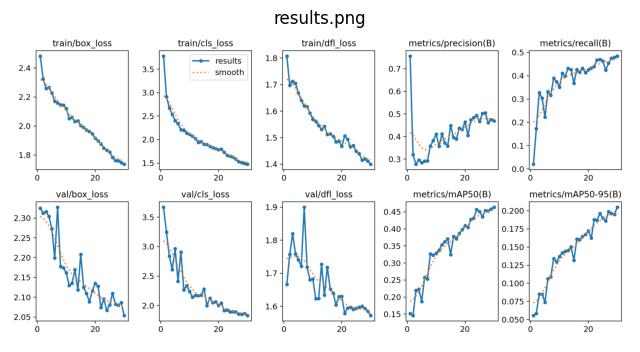

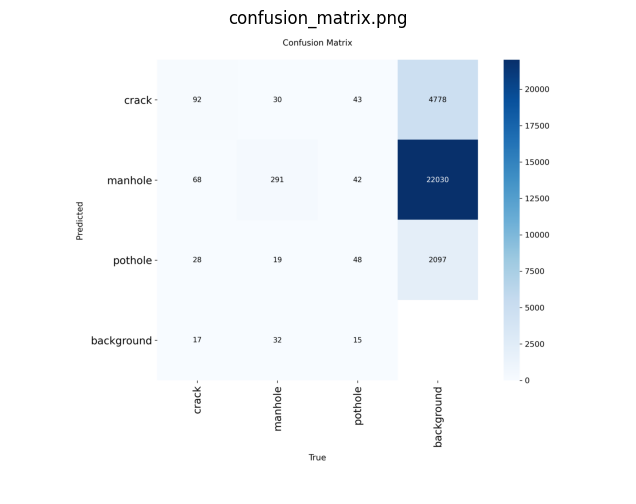

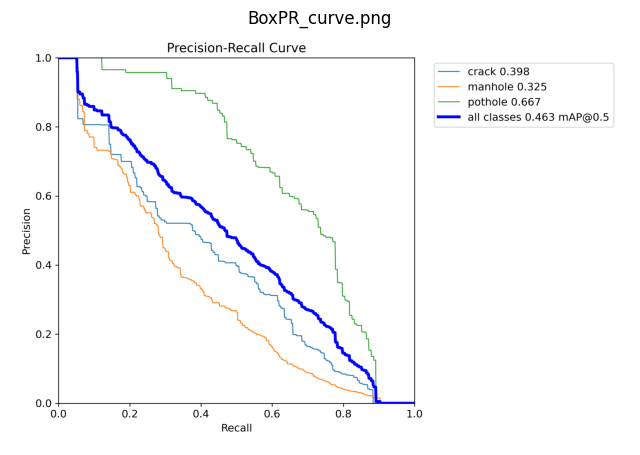

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

results_dir = "/content/runs/detect/RoadDamage_Training/yolov8n_road_damage"

figures = [
    "results.png",
    "confusion_matrix.png",
    "BoxPR_curve.png"
]

for fig in figures:
    plt.figure(figsize=(8,6))
    plt.imshow(Image.open(f"{results_dir}/{fig}"))
    plt.title(fig)
    plt.axis("off")
    plt.show()

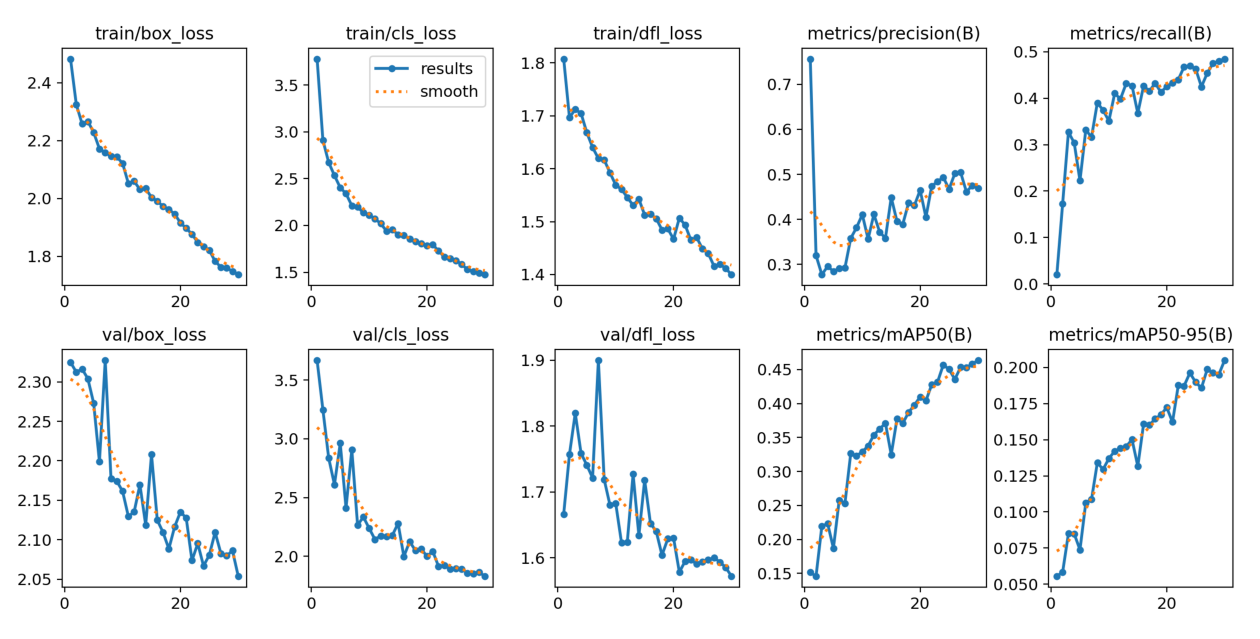

In [24]:
# ==========================================================
# Visualize training metrics
# ==========================================================

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/results.png")

plt.figure(figsize=(16,10))
plt.imshow(img)
plt.axis("off")
plt.show()

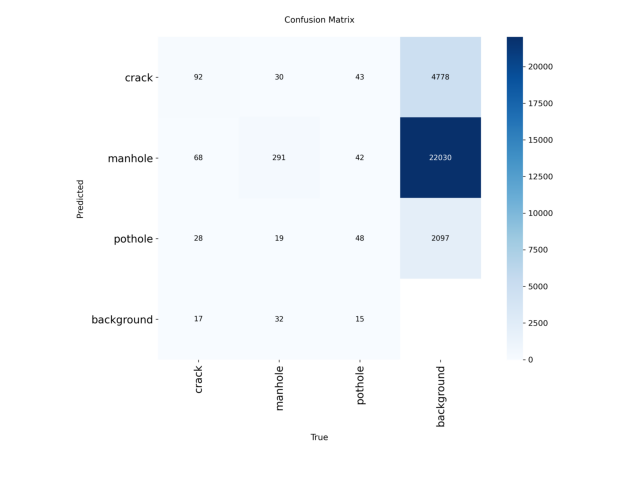

In [25]:
# ==========================================================
# Visualize the confusion matrix
# ==========================================================

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/confusion_matrix.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

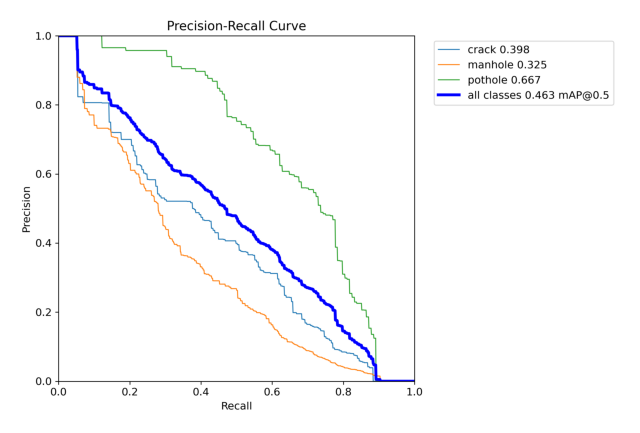

In [26]:
# ==========================================================
# Visualize the confusion matrix
# ==========================================================

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/BoxPR_curve.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

# Conclusion

This notebook presented the complete development of a lightweight road damage detection system using **YOLOv8 Nano**. The workflow covered dataset preparation, preprocessing, model training, evaluation, and inference using a custom road damage dataset containing **cracks, manholes, and potholes**.

The trained model demonstrated the ability to detect multiple categories of road damage, with the strongest performance observed for pothole detection. Although smaller defects such as cracks remain more challenging, the results demonstrate that lightweight object detection models provide a practical foundation for automated road inspection and intelligent transportation systems.

This notebook focuses on the end-to-end object detection pipeline. Model explainability using **EigenCAM** is presented separately in a dedicated notebook to maintain a clear separation between model development and interpretation.

## Next Steps

Future work will extend this project by integrating **EigenCAM** to visualize the image regions that contribute most strongly to the detector's internal feature representations. Additional improvements may include larger YOLOv8 variants, advanced data augmentation, real-time deployment, and evaluation on larger road damage datasets.